In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

In [2]:
# Sample KPI / system performance data
data = {
    "time": list(range(1, 21)),
    "cpu_usage": [20, 22, 19, 21, 23, 24, 20, 22, 85, 21, 23, 19, 20, 90, 22, 21, 20, 23, 88, 22]
}

df = pd.DataFrame(data)
df

,time,cpu_usage
0,1,20
1,2,22
2,3,19
3,4,21
4,5,23
5,6,24
6,7,20
7,8,22
8,9,85
9,10,21


In [3]:
# Apply Isolation Forest
model = IsolationForest(contamination=0.15, random_state=42)
df["anomaly"] = model.fit_predict(df[["cpu_usage"]])

df

,time,cpu_usage,anomaly
0,1,20,1
1,2,22,1
2,3,19,1
3,4,21,1
4,5,23,1
5,6,24,1
6,7,20,1
7,8,22,1
8,9,85,-1
9,10,21,1


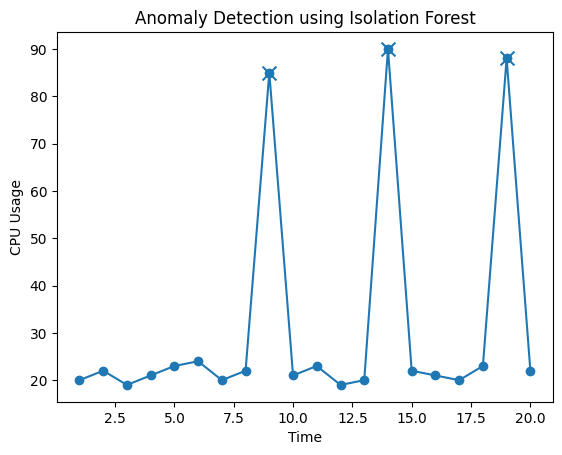

In [4]:
# Visualize anomalies
normal = df[df["anomaly"] == 1]
anomaly = df[df["anomaly"] == -1]

plt.plot(df["time"], df["cpu_usage"], marker="o")
plt.scatter(anomaly["time"], anomaly["cpu_usage"], marker="x", s=100)
plt.xlabel("Time")
plt.ylabel("CPU Usage")
plt.title("Anomaly Detection using Isolation Forest")
plt.show()